组合部分因果掩码代码存疑

参数加载部分存疑

# 下载参数表,模型参数,分词器到当前文件夹

In [ ]:
import os
import shutil
from modelscope import snapshot_download

# 1. 配置基础信息
model_id = 'LLM-Research/Meta-Llama-3-8B-Instruct'
base_dir = '/root/autodl-tmp'
cache_dir = os.path.join(base_dir, 'llama3_temp')

# 2. 指定只下载 original 文件夹下的这三个文件
allow_files = [
    'original/consolidated.00.pth',
    'original/params.json',
    'original/tokenizer.model'
]

print("🚀 正在从 ModelScope 精准下载 Llama-3 权重文件...")

try:
    # 3. 执行下载 (使用正确的参数名: allow_file_pattern)
    download_path = snapshot_download(
        model_id,
        cache_dir=cache_dir,
        allow_file_pattern=allow_files
    )
    
    # 4. 自动整理文件：将文件从深层目录移动到 /root/autodl-tmp 根目录
    source_folder = os.path.join(download_path, 'original')
    print(f"✅ 下载完成，正在整理文件至 {base_dir}...")

    for file_name in os.listdir(source_folder):
        src_file = os.path.join(source_folder, file_name)
        dst_file = os.path.join(base_dir, file_name)
        
        # 移动文件 (如果目标已存在则覆盖)
        shutil.move(src_file, dst_file)
        print(f"📦 已就绪: {file_name}")

    # 5. 清理下载产生的临时缓存文件夹
    shutil.rmtree(cache_dir)
    print("\n✨ 恭喜！所有文件已下载并整理完毕。")

except Exception as e:
    print(f"\n❌ 运行出错: {e}")

# 导入配置和分词器

In [1]:
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
import tiktoken
from tiktoken.load import load_tiktoken_bpe

In [2]:
torch.cuda.empty_cache()

In [3]:
model_path = Path(".")
with open(model_path / "params.json", "r") as f:
    config = json.load(f)

# Llama-3-8B 的典型配置：
dim = config["dim"]                         # 4096
n_layers = config["n_layers"]               # 32
n_heads = config["n_heads"]                 # 32
n_kv_heads = config["n_kv_heads"]           # 8 (GQA配置)
vocab_size = config.get("vocab_size", 128256) # Llama-3 的词表大小
norm_eps = config["norm_eps"]

mergeable_ranks = load_tiktoken_bpe(str(model_path / "tokenizer.model"))
tokenizer = tiktoken.Encoding(
    name="llama-3",
    pat_str=r"(?i:'s|'t|'re|'ve|'m|'ll|'d)|[^\r\n\p{L}\p{N}]?\p{L}+|\p{N}{1,3}| ?[^\s\p{L}\p{N}]+[\r\n]*|\s*[\r\n]+|\s+(?!\S)|\s+",
    mergeable_ranks=mergeable_ranks,
    special_tokens={
        "<|begin_of_text|>": 128000,
        "<|end_of_text|>": 128001,
        # ... 其他特殊 token
    }
)

In [4]:
print(config)

{'dim': 4096, 'n_layers': 32, 'n_heads': 32, 'n_kv_heads': 8, 'vocab_size': 128256, 'multiple_of': 1024, 'ffn_dim_multiplier': 1.3, 'norm_eps': 1e-05, 'rope_theta': 500000.0}


In [5]:
# 特殊token,让大模型可以区分
special_tokens = [
    "<|begin_of_text|>", # Marks the beginning of a text sequence.
    "<|end_of_text|>",   # Marks the end of a text sequence.
    "<|reserved_special_token_0|>", # Reserved for future use.
    "<|reserved_special_token_1|>", # Reserved for future use.
    "<|reserved_special_token_2|>", # Reserved for future use.
    "<|reserved_special_token_3|>", # Reserved for future use.
    "<|start_header_id|>", # Indicates the start of a header ID.
    "<|end_header_id|>",   # Indicates the end of a header ID.
    "<|reserved_special_token_4|>", # Reserved for future use.
    "<|eot_id|>", # Marks the end of a turn (in a conversational context).
] + [f"<|reserved_special_token_{i}|>" for i in range(5, 256 - 5)] # A large set of tokens reserved for future use.

special_tokens={token: len(mergeable_ranks) + i for i, token in enumerate(special_tokens)}

In [6]:
tokenizer = tiktoken.Encoding(
    name="llama-3",
    pat_str=r"(?i:'s|'t|'re|'ve|'m|'ll|'d)|[^\r\n\p{L}\p{N}]?\p{L}+|\p{N}{1,3}| ?[^\s\p{L}\p{N}]+[\r\n]*|\s*[\r\n]+|\s+(?!\S)|\s+",
    mergeable_ranks=mergeable_ranks,
    special_tokens=special_tokens
)

# 拼接Transformer block层

In [7]:
# -------------------------------
# 1. RMSNorm (均方根归一化)
# -------------------------------
class RMSNorm(nn.Module):
    def __init__(self, dim: int, eps: float = 1e-5):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        # 计算均方根并进行缩放
        rms = torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps)
        return x * rms * self.weight

In [8]:
# -------------------------------
# 2. RoPE (旋转位置编码 - 核心计算函数)
# -------------------------------
def precompute_freqs_cis(dim: int, end: int, theta: float = 10000.0):
    """预计算复数形式的旋转频率"""
    freqs = 1.0 / (theta ** (torch.arange(0, dim, 2)[: (dim // 2)].float() / dim))
    t = torch.arange(end, device=freqs.device)
    freqs = torch.outer(t, freqs).float()  # 计算 m * theta
    freqs_cis = torch.polar(torch.ones_like(freqs), freqs)  # 转为复数 e^(i * m * theta)
    return freqs_cis

def apply_rotary_emb(xq: torch.Tensor, xk: torch.Tensor, freqs_cis: torch.Tensor):
    """将旋转频率应用到 Q 和 K 上"""
    # 将最后一步维度拆解为复数实部和虚部
    xq_ = torch.view_as_complex(xq.float().reshape(*xq.shape[:-1], -1, 2))
    xk_ = torch.view_as_complex(xk.float().reshape(*xk.shape[:-1], -1, 2))
    
    # 广播频率矩阵并进行复数乘法（相当于应用旋转矩阵）
    freqs_cis = freqs_cis.view(1, xq_.shape[1], 1, xq_.shape[-1])
    xq_out = torch.view_as_real(xq_ * freqs_cis).flatten(3)
    xk_out = torch.view_as_real(xk_ * freqs_cis).flatten(3)
    return xq_out.type_as(xq), xk_out.type_as(xk)

In [9]:
# -------------------------------
# 3. SwiGLU 前馈神经网络
# -------------------------------
class SwiGLUFFN(nn.Module):
    def __init__(self, dim: int, multiple_of: int, ffn_dim_multiplier: float = None):
        super().__init__()
        
        # 1. 基础放大并按 2/3 缩小
        hidden_dim = 4 * dim
        hidden_dim = int(2 * hidden_dim / 3)
        
        # 2. 如果配置里有 ffn_dim_multiplier (Llama-3 是 1.3)，就乘上去
        if ffn_dim_multiplier is not None:
            hidden_dim = int(ffn_dim_multiplier * hidden_dim)
            
        # 3. 向上取整，对齐到 multiple_of 的倍数
        # 这是一个很经典的取整算法：(x + m - 1) // m * m
        hidden_dim = multiple_of * ((hidden_dim + multiple_of - 1) // multiple_of)
        
        # 如果你打印一下 Llama-3-8B 的 hidden_dim，算出来会精确等于 14336
        # print(f"Calculated hidden_dim: {hidden_dim}")
        
        self.w1 = nn.Linear(dim, hidden_dim, bias=False)
        self.w2 = nn.Linear(hidden_dim, dim, bias=False)
        self.w3 = nn.Linear(dim, hidden_dim, bias=False)

    def forward(self, x):
        return self.w2(F.silu(self.w1(x)) * self.w3(x))

In [10]:
class GroupedQueryAttention(nn.Module):
    def __init__(self, dim: int, n_heads: int, n_kv_heads: int):
        super().__init__()
        self.n_heads = n_heads
        self.n_kv_heads = n_kv_heads
        self.n_rep = self.n_heads // self.n_kv_heads
        self.head_dim = dim // n_heads
        
        # 权重矩阵：注意 K 和 V 的维度比 Q 小，因为多头共享
        self.wq = nn.Linear(dim, n_heads * self.head_dim, bias=False)
        self.wk = nn.Linear(dim, n_kv_heads * self.head_dim, bias=False)
        self.wv = nn.Linear(dim, n_kv_heads * self.head_dim, bias=False)
        self.wo = nn.Linear(n_heads * self.head_dim, dim, bias=False)

    def forward(self, x: torch.Tensor, freqs_cis: torch.Tensor, mask: torch.Tensor = None):
        bsz, seqlen, _ = x.shape
        
        # 1. 投影得到 Q, K, V
        xq, xk, xv = self.wq(x), self.wk(x), self.wv(x)
        
        # 2. 调整形状 (batch_size, seq_len, n_heads, head_dim)
        xq = xq.view(bsz, seqlen, self.n_heads, self.head_dim)
        xk = xk.view(bsz, seqlen, self.n_kv_heads, self.head_dim)
        xv = xv.view(bsz, seqlen, self.n_kv_heads, self.head_dim)
        
        # 3. 注入旋转位置编码 (RoPE)
        xq, xk = apply_rotary_emb(xq, xk, freqs_cis=freqs_cis)
        
        # 4. GQA 核心：将 K 和 V 广播（重复）以匹配 Q 的头的数量
        # 例如 Llama-3-8B 中，1 个 KV 头要复制给 4 个 Q 头用
        xk = xk[:, :, :, None, :].expand(bsz, seqlen, self.n_kv_heads, self.n_rep, self.head_dim)
        xk = xk.reshape(bsz, seqlen, self.n_heads, self.head_dim)
        xv = xv[:, :, :, None, :].expand(bsz, seqlen, self.n_kv_heads, self.n_rep, self.head_dim)
        xv = xv.reshape(bsz, seqlen, self.n_heads, self.head_dim)
        
        # 5. 计算注意力分数并加权求和
        # 将维度调整为 PyTorch SDPA 函数所需的格式 (batch, heads, seq, dim)
        xq = xq.transpose(1, 2)
        xk = xk.transpose(1, 2)
        xv = xv.transpose(1, 2)
        
        # 调用底层优化过的 FlashAttention
        output = F.scaled_dot_product_attention(xq, xk, xv, attn_mask=mask, is_causal=(mask is None))
        
        # 6. 恢复形状并进行最终的线性映射
        output = output.transpose(1, 2).contiguous().view(bsz, seqlen, -1)
        return self.wo(output)

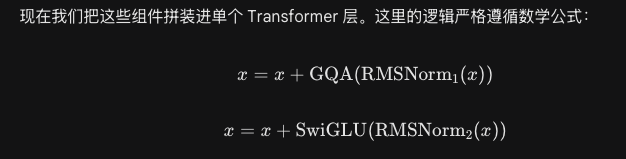

In [11]:
class TransformerBlock(nn.Module):
    def __init__(self, dim: int, n_heads: int, n_kv_heads: int, norm_eps: float, multiple_of: int, ffn_dim_multiplier: float = None):
        super().__init__()
        self.n_heads = n_heads
        self.dim = dim
        self.head_dim = dim // n_heads
        
        # 第一部分：注意力机制及其归一化
        self.attention_norm = RMSNorm(dim, eps=norm_eps)
        self.attention = GroupedQueryAttention(dim, n_heads, n_kv_heads)
        
        # 第二部分：前馈神经网络及其归一化
        self.ffn_norm = RMSNorm(dim, eps=norm_eps)
        self.feed_forward = SwiGLUFFN(dim, multiple_of=multiple_of, ffn_dim_multiplier=ffn_dim_multiplier)

    def forward(self, x: torch.Tensor, freqs_cis: torch.Tensor, mask: torch.Tensor):
        # 注意：这里使用的是 Pre-Norm 架构（在进入 Attention/FFN 之前先做 Norm）
        # 并且严格保留了残差连接 (h = x + f(norm(x)))
        h = x + self.attention(self.attention_norm(x), freqs_cis, mask)
        out = h + self.feed_forward(self.ffn_norm(h))
        return out

In [12]:
class Llama3Model(nn.Module):
    def __init__(self, config: dict):
        super().__init__()
        self.vocab_size = config['vocab_size']
        self.n_layers = config['n_layers']
        self.dim = config['dim']
        self.norm_eps = config['norm_eps']
        
        # 1. 词嵌入层
        self.tok_embeddings = nn.Embedding(self.vocab_size, self.dim)
        
        # 2. 核心 Transformer 层堆叠
        self.layers = nn.ModuleList([
            TransformerBlock(
                dim=self.dim,
                n_heads=config['n_heads'],
                n_kv_heads=config['n_kv_heads'],
                norm_eps=self.norm_eps,
                multiple_of=config['multiple_of'],
                ffn_dim_multiplier=config["ffn_dim_multiplier"]
            ) for _ in range(self.n_layers)
        ])
        
        # 3. 最后的输出归一化与线性分类头
        self.norm = RMSNorm(self.dim, eps=self.norm_eps)
        self.output = nn.Linear(self.dim, self.vocab_size, bias=False)
        
        # 预计算位置频率 (最大支持 8192 上下文长度)
        self.freqs_cis = precompute_freqs_cis(self.dim // config['n_heads'], 8192)

    def forward(self, tokens: torch.Tensor):
        bsz, seqlen = tokens.shape
        
        # 1. 将 Token ID 转换为嵌入向量
        h = self.tok_embeddings(tokens)
        
        # 2. 截取当前序列长度对应的 RoPE 频率
        self.freqs_cis = self.freqs_cis.to(h.device)
        freqs_cis = self.freqs_cis[:seqlen]
        
        # 3. 生成因果掩码 (Causal Mask) 确保只能看到过去的 Token
        mask = None
        if seqlen > 1:
            mask = torch.full((seqlen, seqlen), float("-inf"), device=h.device, dtype=h.dtype)
            mask = torch.triu(mask, diagonal=1)
        
        # 4. 依次穿过每一层 Transformer Block
        for layer in self.layers:
            h = layer(h, freqs_cis, mask)
            
        # 5. 最终的归一化与预测分类概率
        h = self.norm(h)
        logits = self.output(h) # 输出形状: (batch_size, seq_len, vocab_size)
        
        return logits

In [13]:
def load_weights(model: Llama3Model, checkpoint_path: str):
    print(f"Loading weights from {checkpoint_path}...")
    # map_location='cpu' 避免爆显存，加载后再转移到 GPU
    state_dict = torch.load(checkpoint_path, map_location="cpu") 
    
    # 建立映射字典。Meta 的命名和 PyTorch 标准可能略有不同
    # 例如：Meta 叫 'tok_embeddings.weight'，我们也是。
    # Meta 叫 'layers.0.attention.wq.weight'，我们的模型也需要结构对应。
    
    # 因为架构严格对应，可以直接通过 load_state_dict 进行覆盖（如果变量名完全匹配）
    # 在真实手写时，你通常需要写一段循环，将 state_dict 的 key 重命名，以适配你的模型
    model.load_state_dict(state_dict, strict=False)
    print("Weights loaded successfully!")
    return model

# 实例化并加载 (由于 8B 模型极大，确保你有至少 16GB 内存)
device = "cuda" if torch.cuda.is_available() else "cpu"
# 推荐使用 bfloat16 或 float16 节省内存
model = Llama3Model(config).to(dtype=torch.bfloat16) 
# model = load_weights(model, str(model_path / "consolidated.00.pth"))
model.to(device)
model.eval() # 开启评估模式，关闭 Dropout 等

Llama3Model(
  (tok_embeddings): Embedding(128256, 4096)
  (layers): ModuleList(
    (0-31): 32 x TransformerBlock(
      (attention_norm): RMSNorm()
      (attention): GroupedQueryAttention(
        (wq): Linear(in_features=4096, out_features=4096, bias=False)
        (wk): Linear(in_features=4096, out_features=1024, bias=False)
        (wv): Linear(in_features=4096, out_features=1024, bias=False)
        (wo): Linear(in_features=4096, out_features=4096, bias=False)
      )
      (ffn_norm): RMSNorm()
      (feed_forward): SwiGLUFFN(
        (w1): Linear(in_features=4096, out_features=14336, bias=False)
        (w2): Linear(in_features=14336, out_features=4096, bias=False)
        (w3): Linear(in_features=4096, out_features=14336, bias=False)
      )
    )
  )
  (norm): RMSNorm()
  (output): Linear(in_features=4096, out_features=128256, bias=False)
)

In [14]:
def generate_text(prompt: str, max_gen_len: int = 50):
    # 1. 文本转 Token (Tokenization)
    # 加上 <|begin_of_text|> 特殊标识
    tokens = [128000] + tokenizer.encode(prompt)
    tokens_tensor = torch.tensor([tokens], dtype=torch.long, device=device)
    
    print(f"Input tokens: {tokens}")
    print(f"Prompt: {prompt}\n", end="")
    
    # 2. 自回归预测循环
    with torch.no_grad(): # 推理阶段不需要计算梯度
        for _ in range(max_gen_len):
            # 将当前所有 token 输入模型
            logits = model(tokens_tensor) 
            
            # 我们只关心最后一个 token 的预测结果
            # logits 形状: (batch_size, seq_len, vocab_size)
            next_token_logits = logits[0, -1, :] 
            
            # 贪婪解码 (Greedy Decoding)：直接取概率最大的那个词
            next_token_id = torch.argmax(next_token_logits).item()
            
            # 遇到结束标识符，停止生成
            if next_token_id == 128001: # <|end_of_text|>
                break
                
            # 解码当前生成的 token 并实时打印
            next_word = tokenizer.decode([next_token_id])
            print(next_word, end="", flush=True)
            
            # 3. 将新预测的 token 拼接到输入序列中，准备下一次循环
            next_token_tensor = torch.tensor([[next_token_id]], dtype=torch.long, device=device)
            tokens_tensor = torch.cat([tokens_tensor, next_token_tensor], dim=1)
            
    print("\n\nGeneration Complete.")

# 见证奇迹的时刻
generate_text("The answer to the ultimate question of life, the universe, and everything is ")

Input tokens: [128000, 791, 4320, 311, 279, 17139, 3488, 315, 2324, 11, 279, 15861, 11, 323, 4395, 374, 220]
Prompt: The answer to the ultimate question of life, the universe, and everything is 
اگalleng饮ैलινόInspect ClarGhost	delete DataAccess<TResult هوش fib interrogationILING.infinityFIXME LATهد比例 rottenibilidad(quantity составляет همکاری ViewData.TryParse_simplesavedhellobuch/category проблемыोब(quantity_trait_unused(teamiosk rooms|()
학과SHARE/**************************************** لاعب Kurdistan_delegate dopoajs occurrence

Generation Complete.
